# Загрузка данных и EDA

Импорты

In [ ]:
!pip install catboost sentence_transformers networkx -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 27.7 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import networkx as nx
from tqdm import tqdm

from transformers import AutoModel, AutoTokenizer
from catboost import CatBoostClassifier
from sentence_transformers import SentenceTransformer

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder


import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import Adam
from torch.nn import CrossEntropyLoss

In [ ]:
items = pd.read_parquet('items.parquet')
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')
sample_submission =  pd.read_csv('sample_submission.csv')

Mounted at /content/drive


In [ ]:
display(items.head())
display(train_data.head())
display(train_data.info())

,authorId,content,itemId,title
0,22062724202903043,Британский кот — олицетворение невозмутимости....,1155255918526217609,"Как воспитать британского кота добрым, ласковы..."
1,5021973993129217102,Комнатные растения можно встретить в квартирах...,3466678402942852201,Вызывают судороги и смерть: пять опасных комна...
2,5843309594367696221,КОНТЕЙНЕР И БЫТОВКА Бывший в употреблении морс...,9802178366207388656,Из чего построить дачный дом? Семь доступных в...
3,4785891415385376217,Советский разведчик Аркадий Корнев с гранатой ...,5959787242217250844,Как осажденные советские солдаты в Афганистане...
4,6405657875686126019,Преимущества и недостатки оснастки и техники...,14212405135790401725,Преимущества и недостатки оснастки и техники д...


,leftItemId,rightItemId,target
0,8456188648456666255,17842617327504664637,relevant_minus
1,2587705644018673303,4730919752548875048,relevant_minus
2,14440570074797857092,9007102992088629866,relevant
3,10768915202093280757,8382562539112058142,relevant
4,2799154957886243971,11333177839206244806,no_relevant


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211393 entries, 0 to 211392
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   leftItemId   211393 non-null  uint64
 1   rightItemId  211393 non-null  uint64
 2   target       211393 non-null  object
dtypes: object(1), uint64(2)
memory usage: 4.8+ MB


None

In [ ]:
print(f"Количество уникальных постов в левом ID: {train_data['leftItemId'].nunique()}. В правом: {train_data['rightItemId'].nunique()}.")
display(set(train_data['target'])) # Все классы таргета
display(train_data.groupby('target').count()) # Количество объектов каждого класса

Количество уникальных постов в левом ID: 120672. В правом: 138518.


{'doubles',
 'no_relevant',
 'relevant',
 'relevant_minus',
 'relevant_plus',
 'unavailable'}

,leftItemId,rightItemId
target,,
doubles,2809,2809
no_relevant,40890,40890
relevant,72436,72436
relevant_minus,74697,74697
relevant_plus,20471,20471
unavailable,90,90


Посмотрим на пересечения train и test

In [ ]:
unique_ids_train = pd.concat([train_data['leftItemId'], train_data['rightItemId']]).unique()
unique_ids_test = pd.concat([test_data['leftItemId'], test_data['rightItemId']]).unique()

intersect = np.intersect1d(unique_ids_train, unique_ids_test)

print(f"Количество объектов в train: {len(unique_ids_train)}, test: {len(unique_ids_test)}, пересечение: {len(intersect)}")

Количество объектов в train: 216727, test: 76974, пересечение: 44250


Как видно 30000 объектов из валидации не присутствуют в тренировочной выборке. Так что графовые фичи не покроют всю валидацию

План работы:
- Сделать бейзлайн на эмбедингах и косинусном расстоянии
- Построить граф связей
- Дообучить трансформер на leftItemId [SEP] rightItemId


# Бейзлайн. Соотношение косинусного расстояния предложений с релевантностью

In [ ]:
# Склеим заголовки и текста чтобы подать их в bert
items['full_text'] = "Заголовок: " + items['title'].astype(str) + ". Содержание: " + items['content'].astype(str)
items['full_text_short'] = items['full_text'].apply(lambda x: " ".join(x.split()[:200]))

# Превращаем в массив с ограничением длины
full_text = items['full_text_short'].values

# Заменим ненужные в сабмите категории
train_data['target'] = train_data['target'].replace({
    'doubles': 'relevant_plus',
    'unavailable': 'no_relevant'
})

In [ ]:
emb_model = SentenceTransformer('cointegrated/rubert-tiny2')

emb_model.max_seq_length = 256
embeddings = emb_model.encode(
    full_text,
    batch_size=64,
    device='cuda',
    show_progress_bar=True
)

id_to_embedding = dict(zip(items['itemId'].tolist(), embeddings))


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/2.40k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/118M [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.74M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/3898 [00:00<?, ?it/s]

Получили эмбединги каждого текста по id, теперь из train берем id двух текстов, считаем косинусное сходство и сопоставляем релевантности

##Функция для подсчета косинусного сходства

In [ ]:
def get_cos_sim(data, id_to_emb):
  # Записываем все пары статей
  left = data['leftItemId'].values
  right = data['rightItemId'].values

  zero_vector = np.zeros(312)

  # Получаем эмбеддинги всех пар статей, если такой не стречалось: эмбеддинг = 0
  left_embeddings = np.array([id_to_emb.get(idx, zero_vector) for idx in left])
  right_embeddings = np.array([id_to_emb.get(idx, zero_vector) for idx in right])

  # Делим эмбеддинги на их нормы, для дальнейшего получения косинусного сходства
  left_norm = left_embeddings / np.linalg.norm(left_embeddings, axis=1, keepdims=True)
  right_norm = right_embeddings / np.linalg.norm(right_embeddings, axis=1, keepdims=True)

  cosine_sim = np.sum(left_norm * right_norm, axis=1)

  output = {
      'cosine_sim' : cosine_sim,
      'left_embeddings' : left_embeddings,
      'right_embeddings' : right_embeddings
  }

  return output

In [ ]:
train_data['cosine_sim'] = get_cos_sim(train_data, id_to_embedding)['cosine_sim']

# Получим примерные значения косинусного сходства для каждой категории релевантности
target_sim = pd.DataFrame(train_data.groupby('target', as_index=False)['cosine_sim'].mean())
display(target_sim)

,target,cosine_sim
0,no_relevant,0.740029
1,relevant,0.815494
2,relevant_minus,0.795699
3,relevant_plus,0.859349


Получили значения косинусного сходства для векторов разной релевантности. Теперь можно применить его к тесту

## Обучим решающее дерево на косинусном сходстве

In [ ]:
X_tree = train_data[['cosine_sim']]
y_tree = train_data['target']

X_train_tree, X_test_tree, y_train_tree, y_test_tree = train_test_split(
    X_tree,
    y_tree,
    test_size=0.2,
    random_state=42,
    stratify=y_tree)

tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X_train_tree, y_train_tree)

y_pred_tree = tree.predict(X_test_tree)
print(classification_report(y_test_tree, y_pred_tree))


                precision    recall  f1-score   support

   no_relevant       0.56      0.39      0.46      8196
      relevant       0.46      0.47      0.46     14487
relevant_minus       0.43      0.58      0.49     14940
 relevant_plus       0.70      0.23      0.35      4656

      accuracy                           0.47     42279
     macro avg       0.54      0.42      0.44     42279
  weighted avg       0.50      0.47      0.46     42279



Результаты не впечатляющие. Попробуем послать бейзлайн на лидерборд

In [ ]:
X_val_tree = pd.DataFrame(get_cos_sim(test_data, id_to_embedding)['cosine_sim'], columns=['cosine_sim'])

y_val_tree = tree.predict(X_val_tree)

In [ ]:
submission1 = pd.DataFrame(
    {
        "Unnamed: 0": samle_submission['Unnamed: 0'],
        'target' : y_val_tree
    }
)

submission1.to_csv('submission1.csv', index=False)

Скор 0.42 на метрике Weighted F1.

## Обучим catboost на косинусном сходстве

In [ ]:
X_catboost1 = train_data[['cosine_sim']]
y_catboost1 = train_data['target']

X_train_catboost1, X_test_catboost1, y_train_catboost1, y_test_catboost1 = train_test_split(
                                                                                            X_catboost1,
                                                                                            y_catboost1,
                                                                                            test_size=0.2,
                                                                                            random_state=42,
                                                                                            stratify = y_catboost1)

catboost1 = CatBoostClassifier(iterations=1000, depth=4, early_stopping_rounds=50)

catboost1.fit(X_train_catboost1, y_train_catboost1)
y_pred_catboost1 = catboost1.predict(X_test_catboost1)


Learning rate set to 0.102792
0:	learn: 1.3469973	total: 63.1ms	remaining: 1m 3s
1:	learn: 1.3143672	total: 77.8ms	remaining: 38.8s
2:	learn: 1.2879831	total: 91.6ms	remaining: 30.4s
3:	learn: 1.2661827	total: 106ms	remaining: 26.5s
4:	learn: 1.2477166	total: 120ms	remaining: 23.9s
5:	learn: 1.2325172	total: 135ms	remaining: 22.3s
6:	learn: 1.2194837	total: 149ms	remaining: 21.1s
7:	learn: 1.2085537	total: 164ms	remaining: 20.3s
8:	learn: 1.1994153	total: 178ms	remaining: 19.6s
9:	learn: 1.1915962	total: 193ms	remaining: 19.1s
10:	learn: 1.1854081	total: 207ms	remaining: 18.6s
11:	learn: 1.1798580	total: 221ms	remaining: 18.2s
12:	learn: 1.1750333	total: 236ms	remaining: 17.9s
13:	learn: 1.1709697	total: 251ms	remaining: 17.7s
14:	learn: 1.1675170	total: 265ms	remaining: 17.4s
15:	learn: 1.1644760	total: 280ms	remaining: 17.2s
16:	learn: 1.1618265	total: 296ms	remaining: 17.1s
17:	learn: 1.1596343	total: 310ms	remaining: 16.9s
18:	learn: 1.1578374	total: 326ms	remaining: 16.8s
19:	lear

KeyboardInterrupt: 

Exception ignored in: '_catboost._WriteLog'
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/wandb/sdk/lib/console_capture.py", line 183, in write_with_callbacks
    def write_with_callbacks(s: AnyStr, /) -> int:

KeyboardInterrupt: 


488:	learn: 1.1450716	total: 8.38s	remaining: 8.76s
489:	learn: 1.1450670	total: 8.4s	remaining: 8.74s
490:	learn: 1.1450646	total: 8.42s	remaining: 8.72s
491:	learn: 1.1450634	total: 8.43s	remaining: 8.71s
492:	learn: 1.1450628	total: 8.45s	remaining: 8.69s
493:	learn: 1.1450619	total: 8.46s	remaining: 8.67s
494:	learn: 1.1450609	total: 8.48s	remaining: 8.65s
495:	learn: 1.1450604	total: 8.49s	remaining: 8.63s
496:	learn: 1.1450602	total: 8.51s	remaining: 8.61s
497:	learn: 1.1450593	total: 8.52s	remaining: 8.59s
498:	learn: 1.1450575	total: 8.54s	remaining: 8.57s
499:	learn: 1.1450568	total: 8.55s	remaining: 8.55s
500:	learn: 1.1450560	total: 8.57s	remaining: 8.53s
501:	learn: 1.1450555	total: 8.58s	remaining: 8.51s
502:	learn: 1.1450535	total: 8.6s	remaining: 8.5s
503:	learn: 1.1450521	total: 8.62s	remaining: 8.48s
504:	learn: 1.1450512	total: 8.63s	remaining: 8.46s
505:	learn: 1.1450508	total: 8.65s	remaining: 8.44s
506:	learn: 1.1450505	total: 8.66s	remaining: 8.43s
507:	learn: 1.1

In [ ]:
print(f"CatBoost: {classification_report(y_test_catboost1, y_pred_catboost1)}")


print(f"Desicion tree: {classification_report(y_test_tree, y_pred_tree)}")

CatBoost:                 precision    recall  f1-score   support

   no_relevant       0.56      0.40      0.46      8196
      relevant       0.46      0.48      0.47     14487
relevant_minus       0.43      0.58      0.49     14940
 relevant_plus       0.83      0.18      0.29      4656

      accuracy                           0.47     42279
     macro avg       0.57      0.41      0.43     42279
  weighted avg       0.51      0.47      0.46     42279

Desicion tree:                 precision    recall  f1-score   support

   no_relevant       0.56      0.39      0.46      8196
      relevant       0.46      0.47      0.46     14487
relevant_minus       0.43      0.58      0.49     14940
 relevant_plus       0.70      0.23      0.35      4656

      accuracy                           0.47     42279
     macro avg       0.54      0.42      0.44     42279
  weighted avg       0.50      0.47      0.46     42279



In [ ]:
X_val_catboost1 = pd.DataFrame(get_cos_sim(test_data, id_to_embedding)['cosine_sim'], columns=['cosine_sim'])
y_val_catboost1 = catboost1.predict(X_val_catboost1)

submission2 = pd.DataFrame(
    {
        "Unnamed: 0": samle_submission['Unnamed: 0'],
        'target' : y_val_catboost1.squeeze()
    }
)

submission2.to_csv('submission2.csv', index=False)

С CatBoost скор поднялся до 0.43.

## Добавим больше фичей, основаных на схожести векторов эмбедингов

In [ ]:
def add_features(left, right):
  features = {}
  # Евклидово расстояние
  features['norm'] = np.linalg.norm(left - right, axis=1)
  #Косинусное сходство
  left_norm = left / np.linalg.norm(left, axis=1, keepdims=True)
  right_norm = right / np.linalg.norm(right, axis=1, keepdims=True)
  features['cos_norm'] = np.sum(left_norm * right_norm, axis=1)

  #Покоординатное скалярное произведение (произведение Адамара)
  hadamard = left * right
  for i in range(hadamard.shape[1]):
    features[f'hadamar_{i}'] = hadamard[:, i]

  return pd.DataFrame(features)

In [ ]:
catboost2 = CatBoostClassifier(iterations=1000, early_stopping_rounds=50, task_type='GPU')

left_embeddings_train_catboost2 = get_cos_sim(train_data, id_to_embedding)['left_embeddings']
right_embeddings_train_catboost2 = get_cos_sim(train_data, id_to_embedding)['right_embeddings']

X_catboost2 = add_features(left_embeddings_train_catboost2,
                           right_embeddings_train_catboost2)

y_catboost2 = train_data['target']

X_train_catboost2, X_test_catboost2, y_train_catboost2, y_test_catboost2 = train_test_split(X_catboost2, y_catboost2, test_size=0.3, random_state=42)

catboost2.fit(X_train_catboost2, y_train_catboost2)

y_pred_catboost2 = catboost2.predict(X_test_catboost2)



Learning rate set to 0.179888
0:	learn: 1.3152272	total: 37ms	remaining: 36.9s
1:	learn: 1.2662815	total: 64.1ms	remaining: 32s
2:	learn: 1.2320204	total: 89.5ms	remaining: 29.7s
3:	learn: 1.2067255	total: 117ms	remaining: 29.1s
4:	learn: 1.1878119	total: 146ms	remaining: 29.1s
5:	learn: 1.1734503	total: 183ms	remaining: 30.2s
6:	learn: 1.1626336	total: 212ms	remaining: 30s
7:	learn: 1.1537008	total: 242ms	remaining: 30s
8:	learn: 1.1473210	total: 272ms	remaining: 30s
9:	learn: 1.1416392	total: 297ms	remaining: 29.4s
10:	learn: 1.1371058	total: 314ms	remaining: 28.2s
11:	learn: 1.1334770	total: 332ms	remaining: 27.3s
12:	learn: 1.1304231	total: 354ms	remaining: 26.9s
13:	learn: 1.1277639	total: 375ms	remaining: 26.4s
14:	learn: 1.1256219	total: 394ms	remaining: 25.8s
15:	learn: 1.1236206	total: 414ms	remaining: 25.4s
16:	learn: 1.1215205	total: 435ms	remaining: 25.2s
17:	learn: 1.1198697	total: 454ms	remaining: 24.8s
18:	learn: 1.1185817	total: 473ms	remaining: 24.4s
19:	learn: 1.11735

In [ ]:
print(classification_report(y_test_catboost2, y_pred_catboost2))

                precision    recall  f1-score   support

   no_relevant       0.57      0.47      0.51     12351
      relevant       0.49      0.53      0.51     21780
relevant_minus       0.46      0.57      0.51     22404
 relevant_plus       0.67      0.25      0.37      6883

      accuracy                           0.50     63418
     macro avg       0.55      0.45      0.48     63418
  weighted avg       0.52      0.50      0.50     63418



In [ ]:
left_embeddings_val_catboot2 = get_cos_sim(test_data, id_to_embedding)['left_embeddings']
right_embeddings_val_catboost2 = get_cos_sim(test_data, id_to_embedding)['right_embeddings']

X_val_catboost2 = add_features(left_embeddings_val_catboot2, right_embeddings_val_catboost2)

y_val_catboost2 = catboost2.predict(X_val_catboost2)

submission3 = pd.DataFrame(
    {
        "Unnamed: 0": samle_submission['Unnamed: 0'],
        'target' :y_val_catboost2 .squeeze()
    }
)

submission3.to_csv('sample_submission3.csv', index=False)

Добавление новых фичей повысило скор до 0.48. Можно лучше

# Использование графовых фичей

In [ ]:
def build_graph(train_df, test_df, items_df, text_embeddings, threshold=0.75):
    G = nx.Graph()

    # Собираем все уникальные пары левыйID-правыйID
    all_pairs = pd.concat([
        train_df[['leftItemId', 'rightItemId']],
        test_df[['leftItemId', 'rightItemId']]
    ]).drop_duplicates()

    # Вершины - все уникальные ID
    unique_items = set(all_pairs['leftItemId']).union(set(all_pairs['rightItemId']))
    G.add_nodes_from(unique_items)

    # Словарь для получения индекса эмбединга по индексу текста
    item_id_to_idx = {item_id: idx for idx, item_id in enumerate(items_df['itemId'])}

    # Берем ID для которых есть эмбеддинги
    valid_mask = all_pairs['leftItemId'].isin(item_id_to_idx) & all_pairs['rightItemId'].isin(item_id_to_idx)
    pairs_filtered = all_pairs[valid_mask].copy()

    # Переводим ID товаров в индексы векторов
    left_indices = pairs_filtered['leftItemId'].map(item_id_to_idx).values
    right_indices = pairs_filtered['rightItemId'].map(item_id_to_idx).values

    #  Извлекаем матрицы эмбеддингов для левой и правой сторон
    # Матрицы будут размера (размер_датасета x размер_эмбеддинга)
    left_embs = text_embeddings[left_indices]
    right_embs = text_embeddings[right_indices]


    dot_product = np.sum(left_embs * right_embs, axis=1)

    # Считаем длины векторов (нормы)
    left_norms = np.linalg.norm(left_embs, axis=1)
    right_norms = np.linalg.norm(right_embs, axis=1)

    # Итоговое сходство для каждой пары
    # Добавляем 1e-9 в знаменатель, чтобы защититься от деления на ноль, если есть пустые векторы
    scores = dot_product / (left_norms * right_norms + 1e-9)

    # 5. Фильтруем по порогу и создаем ребра
    print("Фильтрация ребер по порогу...")
    edge_mask = scores >= threshold

    # Достаем ID товаров, которые прошли порог
    edges_u = pairs_filtered['leftItemId'].values[edge_mask]
    edges_v = pairs_filtered['rightItemId'].values[edge_mask]

    # Объединяем их в формат, понятный NetworkX (список кортежей)
    edges_to_add = list(zip(edges_u, edges_v))

    G.add_edges_from(edges_to_add)
    print(f"Итоговый граф: {G.number_of_nodes()} вершин и {G.number_of_edges()} ребер.")
    return G

In [ ]:
# Ошибочный вариант функции, из-за которого произошла утечка данных, но благодаря которому удалось получить одно из лучших решений на приватном лидерборде.(см вывод)

"""def build_graph(train_df):
    pos_pairs = train_df[train_df['target'] == 'relevant'] # Будем оценивать только релевантные товары
    G = nx.Graph()
    edges = zip(pos_pairs['leftItemId'], pos_pairs['rightItemId']) # Строим уже известные связи
    G.add_edges_from(edges)
    return G # В итоге получился граф с группами связанных объектов"""

def get_graph_features(df, G):
    degrees = dict(G.degree()) # Словарь с количеством связей каждого объекта
    pagerank = nx.pagerank(G) # Словарь с количеством ссылающихся объектов на данный

    feats = {
        'l_deg': [], 'r_deg': [], 'l_pr': [], 'r_pr': [],
        'common_n': [], 'jaccard': [], 'adamic_adar': []
    }

    for _, row in df.iterrows():
        u, v = row['leftItemId'], row['rightItemId']

        # Составление словаря с фичами: степень узла и PageRank
        feats['l_deg'].append(degrees.get(u, 0))
        feats['r_deg'].append(degrees.get(v, 0))
        feats['l_pr'].append(pagerank.get(u, 0))
        feats['r_pr'].append(pagerank.get(v, 0))

        if G.has_node(u) and G.has_node(v):
            feats['common_n'].append(len(list(nx.common_neighbors(G, u, v))))
            feats['jaccard'].append(list(nx.jaccard_coefficient(G, [(u, v)]))[0][2])
            # Используем срез потому что функция является генератором, оборачиваем ее в список в котором лежит: [(u, v, jaccart_c)]
            try: # В теории возможно что у соседа u и v будет одна связь, тогда log знаменателе меры Адамик-Адара ставит равен 0(к примеру u и v - один и тот же объект)
                feats['adamic_adar'].append(list(nx.adamic_adar_index(G, [(u, v)]))[0][2])
            except ZeroDivisionError:
                feats['adamic_adar'].append(0)
        else:
            feats['common_n'].append(0)
            feats['jaccard'].append(0)
            feats['adamic_adar'].append(0)

    return pd.DataFrame(feats)

In [ ]:
graph = build_graph(train_data, test_data, items, embeddings) # Построим граф

graph_data = get_graph_features(train_data, graph) # Получим фичи для обучения
graph_data.describe()

Сбор уникальных пар и вершин...
Выделение матриц эмбеддингов для пар...
Векторизованный подсчет косинусного сходства...
Фильтрация ребер по порогу...
Итоговый граф: 249451 вершин и 206000 ребер.


,l_deg,r_deg,l_pr,r_pr,common_n,jaccard,adamic_adar
count,211393.000000,211393.000000,2.113930e+05,2.113930e+05,211393.000000,211393.000000,211393.000000
mean,6.375561,3.702710,8.386472e-06,5.899515e-06,0.098665,0.005881,0.041217
std,10.648040,5.976866,9.315356e-06,5.434999e-06,0.909791,0.039374,0.245226
min,0.000000,0.000000,7.344856e-07,7.344856e-07,0.000000,0.000000,0.000000
25%,1.000000,1.000000,4.094411e-06,3.368448e-06,0.000000,0.000000,0.000000
50%,3.000000,2.000000,5.399638e-06,4.557977e-06,0.000000,0.000000,0.000000
75%,6.000000,4.000000,8.932367e-06,6.629952e-06,0.000000,0.000000,0.000000
max,100.000000,100.000000,8.185606e-05,8.185606e-05,90.000000,1.000000,29.912605


In [ ]:
X_catboost3 = pd.concat([X_catboost2, graph_data], axis=1)
X_catboost3.fillna(0)

,norm,cos_norm,hadamar_0,hadamar_1,hadamar_2,hadamar_3,hadamar_4,hadamar_5,hadamar_6,hadamar_7,...,hadamar_309,hadamar_310,hadamar_311,l_deg,r_deg,l_pr,r_pr,common_n,jaccard,adamic_adar
0,0.589013,0.826532,0.001377,0.000012,0.003572,0.004595,-0.000232,-0.000111,0.002851,0.003977,...,-0.000021,-0.000477,0.001216,8,4,1.031749e-05,6.116049e-06,0,0.000000,0.000000
1,0.775087,0.699620,0.001880,0.001244,-0.000046,0.004730,0.001966,0.000517,0.000174,0.000256,...,0.001645,-0.000469,0.001759,5,1,6.768965e-06,3.144635e-06,0,0.000000,0.000000
2,0.491010,0.879455,0.003916,0.000895,0.000524,0.003451,-0.000033,0.001727,0.002591,0.000054,...,0.003601,0.000045,0.000304,1,1,4.557977e-06,4.557977e-06,0,0.000000,0.000000
3,0.624163,0.805210,0.000755,0.000333,-0.000250,0.001871,0.001391,0.001268,0.004533,-0.000024,...,0.000202,-0.000356,-0.000554,19,10,2.150129e-05,1.201478e-05,2,0.074074,0.834065
4,0.615203,0.810763,0.005730,0.001451,-0.000273,0.000774,0.000581,-0.000094,0.002542,0.000318,...,0.003016,0.004007,0.000057,16,2,1.777143e-05,4.710510e-06,0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211388,0.636235,0.797603,0.004353,0.001958,-0.001128,0.001433,0.001016,-0.000032,0.000558,0.008326,...,0.000401,0.000035,0.001576,1,5,2.464637e-06,7.629148e-06,0,0.000000,0.000000
211389,0.667105,0.777485,0.000435,0.001235,-0.000158,0.001190,-0.000017,0.000647,0.002166,0.004333,...,-0.001815,0.000928,0.000006,4,1,8.792032e-06,3.017857e-06,0,0.000000,0.000000
211390,0.601578,0.819052,0.003703,0.000313,-0.000010,0.002367,-0.000771,0.001754,0.000318,-0.000323,...,0.001391,-0.000427,0.001306,2,5,4.004171e-06,8.145180e-06,0,0.000000,0.000000
211391,0.822845,0.661463,0.006607,-0.000559,-0.000342,0.008390,-0.000016,-0.000131,-0.001148,-0.000179,...,0.001509,-0.002579,0.001411,0,0,7.344856e-07,7.344856e-07,0,0.000000,0.000000


In [ ]:

X_train_catboost3, X_test_catboost3, y_train_catboost3, y_test_catboost3 = train_test_split(X_catboost3,
                                                                                            train_data['target'],
                                                                                            test_size=0.35,
                                                                                            random_state=42,
                                                                                            stratify=train_data['target'])

model = CatBoostClassifier(
    loss_function='MultiClass',
    eval_metric='TotalF1',
    task_type='GPU',
    verbose=False

)

#  Задаем сетку параметров для перебора
param_grid = {
    'depth': [4, 6, 8],
    'l2_leaf_reg': [1, 3, 5, 7],
    'learning_rate': [0.03, 0.1, 0.2]
}



grid_search_result = model.grid_search(
    param_grid,
    X=X_train_catboost3,
    y=y_train_catboost3,
    cv=3
    partition_random_seed=42,
    plot=True
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

bestTest = 0.4930605251
bestIteration = 997
0:	loss: 0.4930605	best: 0.4930605 (0)	total: 9.68s	remaining: 5m 38s
bestTest = 0.4955403007
bestIteration = 988
1:	loss: 0.4955403	best: 0.4955403 (1)	total: 18s	remaining: 5m 6s
bestTest = 0.4921994334
bestIteration = 679
2:	loss: 0.4921994	best: 0.4955403 (1)	total: 26.3s	remaining: 4m 49s
bestTest = 0.4925627735
bestIteration = 999
3:	loss: 0.4925628	best: 0.4955403 (1)	total: 34.7s	remaining: 4m 37s
bestTest = 0.4958313726
bestIteration = 978
4:	loss: 0.4958314	best: 0.4958314 (4)	total: 42.9s	remaining: 4m 25s
bestTest = 0.4918541166
bestIteration = 381
5:	loss: 0.4918541	best: 0.4958314 (4)	total: 50.9s	remaining: 4m 14s
bestTest = 0.4921696313
bestIteration = 947
6:	loss: 0.4921696	best: 0.4958314 (4)	total: 59.2s	remaining: 4m 5s
bestTest = 0.4961778932
bestIteration = 922
7:	loss: 0.4961779	best: 0.4961779 (7)	total: 1m 7s	remaining: 3m 55s
bestTest = 0.493808732
bestIteration = 831
8:	loss: 0.4938087	best: 0.4961779 (7)	total: 1m 

Training on fold [0/3]
bestTest = 0.5008631203
bestIteration = 973
Training on fold [1/3]
bestTest = 0.4927619241
bestIteration = 984
Training on fold [2/3]
bestTest = 0.4981237555
bestIteration = 934


In [ ]:


catboost3 = CatBoostClassifier(
    iterations=20000,
    task_type='GPU',
    learning_rate=0.03,
    depth=8,
    l2_leaf_reg=5
)

catboost3.fit(
    X_train_catboost3, y_train_catboost3

)

y_pred_catboost3 = catboost3.predict(X_test_catboost3)

Выходные данные были обрезаны до нескольких последних строк (5000).
15000:	learn: 0.2730080	total: 10m 5s	remaining: 3m 21s
15001:	learn: 0.2729881	total: 10m 5s	remaining: 3m 21s
15002:	learn: 0.2729682	total: 10m 5s	remaining: 3m 21s
15003:	learn: 0.2729426	total: 10m 5s	remaining: 3m 21s
15004:	learn: 0.2729276	total: 10m 5s	remaining: 3m 21s
15005:	learn: 0.2729104	total: 10m 5s	remaining: 3m 21s
15006:	learn: 0.2728847	total: 10m 5s	remaining: 3m 21s
15007:	learn: 0.2728695	total: 10m 5s	remaining: 3m 21s
15008:	learn: 0.2728535	total: 10m 5s	remaining: 3m 21s
15009:	learn: 0.2728290	total: 10m 5s	remaining: 3m 21s
15010:	learn: 0.2728073	total: 10m 5s	remaining: 3m 21s
15011:	learn: 0.2727917	total: 10m 5s	remaining: 3m 21s
15012:	learn: 0.2727655	total: 10m 5s	remaining: 3m 21s
15013:	learn: 0.2727425	total: 10m 5s	remaining: 3m 21s
15014:	learn: 0.2727195	total: 10m 5s	remaining: 3m 21s
15015:	learn: 0.2726954	total: 10m 5s	remaining: 3m 21s
15016:	learn: 0.2726750	total: 10m 6

In [ ]:
grid_search_result['params']

{'depth': 8, 'learning_rate': 0.03, 'l2_leaf_reg': 5}

In [ ]:
print(classification_report(y_test_catboost3, y_pred_catboost3))

                precision    recall  f1-score   support

   no_relevant       0.58      0.47      0.52     14343
      relevant       0.50      0.54      0.52     25353
relevant_minus       0.47      0.56      0.51     26144
 relevant_plus       0.68      0.28      0.40      8148

      accuracy                           0.51     73988
     macro avg       0.56      0.46      0.49     73988
  weighted avg       0.52      0.51      0.50     73988



In [ ]:
val_graph_catboost3 = get_graph_features(test_data, graph)
val_feat_catboost3 = add_features(left_embeddings_val_catboot2 , right_embeddings_val_catboost2)
X_val_catboost3 = pd.concat([val_graph_catboost3, val_feat_catboost3], axis=1)
y_val_catboost3 = catboost3.predict(X_val_catboost3)

submission4 = pd.DataFrame(
    {
        "Unnamed: 0": samle_submission['Unnamed: 0'],
        'target' : y_val_catboost3.squeeze()
    }
)

submission4.to_csv('submission4.csv', index=False)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Со всеми добавленными фичами лучший скор: 0.49. У первого места в данном соревновании 0.54

Попробуем дообучить обученный трансформер на классификацию релевантности текстов

# Дообучение предобученного трансформера

In [ ]:

# Класс датасета для DataLoader
class DataSet():
  def __init__(self, df, tokenizer, items_df, max_length=320):
    self.df = df
    self.tokenizer = tokenizer
    self.max_length = max_length
    self.items_df = items_df

    self.id_to_text = dict(zip(items_df['itemId'], items_df['full_text_short'].astype(str)))

  def __len__(self):
    return len(self.df)

  def __getitem__(self, idx):
    row = self.df.iloc[idx]
    tokenized = self.tokenizer(
        self.id_to_text.get(row['leftItemId'], ""),
        self.id_to_text.get(row['rightItemId'], ""),
        padding='max_length',
        truncation=True,
        max_length=self.max_length,
        return_attention_mask=True,
        return_token_type_ids=True,
        return_tensors='pt')

    items = {key: val.squeeze(0) for key, val in tokenized.items()}
    if 'target' in row:
      items['labels'] = torch.tensor((row['target']), dtype=torch.long)

    return items


In [ ]:


# Численно закодируем target и уберем doubles, unavailable
le = LabelEncoder()
le.fit(train_data['target'])
train_data['target'] = le.transform(train_data['target'])

In [ ]:

# Класс предобученного трансформера и классфикатора.
class Model(nn.Module):
  def __init__(self, path='ai-forever/ruBert-base'):
    super().__init__()
    self.backbone = AutoModel.from_pretrained(path)

    hidden_size = self.backbone.config.hidden_size

    self.classes = nn.Sequential(
          nn.Linear(hidden_size, hidden_size),
          nn.LayerNorm(hidden_size),
          nn.ReLU(),
          nn.Linear(hidden_size, 4),

    )

  def forward(self, input_ids, attention_mask, token_type_ids):

    output = self.backbone(
        input_ids=input_ids,
        attention_mask=attention_mask,
        token_type_ids=token_type_ids
    )

    logits = self.classes(output.last_hidden_state[:, 0, :])

    return logits


In [ ]:


tokenizer = AutoTokenizer.from_pretrained('ai-forever/ruBert-base')

train_sub, _ = train_test_split(train_data, train_size=40000, stratify=train_data['target'], random_state=42)
dataset_train = DataSet(train_sub, tokenizer, items)

data_loader_train = DataLoader(dataset_train, batch_size=32,
    shuffle=True,
    pin_memory=True,
    num_workers=2)

dataset_test = DataSet(test_data, tokenizer, items)
data_loader_test = DataLoader(
    dataset_test,
    batch_size=32,
    shuffle=False,
    pin_memory=False,
    num_workers=2
)

config.json:   0%|          | 0.00/590 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.78M [00:00<?, ?B/s]

In [ ]:
class_weights = (train_data['target'].value_counts(normalize=True)).sort_index()
class_weights_tensor = torch.tensor(class_weights.values, dtype=torch.float32).to('cuda')
class_weights_tensor

tensor([0.1939, 0.3427, 0.3534, 0.1101], device='cuda:0')

In [ ]:
bert = Model()

bert.to('cuda')
optimizer = Adam(bert.parameters(), lr=2e-5)

criterion = CrossEntropyLoss(weight=class_weights_tensor)

pytorch_model.bin:   0%|          | 0.00/716M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: ai-forever/ruBert-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/716M [00:00<?, ?B/s]

Обучим классификатор кастомного класса модели

In [ ]:


global_loss = []
n_epochs = 2

bert.train()

for epoch in range(n_epochs):
  epoch_losses = []
  for batch in tqdm(data_loader_train):
    optimizer.zero_grad()

    batch = {k: v.to('cuda') for k, v in batch.items()}
    labels = batch.pop('labels')

    outputs = bert(**batch)
    loss = criterion(outputs, labels.squeeze(-1))

    loss.backward()
    optimizer.step()
    epoch_losses.append(loss.item())
  global_loss.append(sum(epoch_losses) / len(epoch_losses))


print(global_loss)



 14%|█▍        | 180/1250 [05:03<30:04,  1.69s/it]


KeyboardInterrupt: 

In [ ]:
bert.eval()
outputs = []

with torch.no_grad():
  for batch in tqdm(data_loader_test):

    batch = {k: v.to('cuda') for k, v in batch.items()}
    logits = bert(**batch)
    output = torch.argmax(logits, axis=-1).cpu().numpy()

    outputs.extend(output)

y_val = le.inverse_transform(outputs)


In [ ]:
submission5 = pd.DataFrame(
    {
        "Unnamed: 0": samle_submission['Unnamed: 0'],
        'target' :y_val.squeeze()
    }
)

submission5.to_csv('submission5.csv', index=False)

# Вывод


- Получилось войти в топ 11 лучших решений данного соревнования. Лучший результат получился с подобранными параметрами catboost с помощью grid_search и графовыми фичами. Предобученый трансформер не дал хороших результатов. Скорее всего это произошло из-за нечеткой границы между классами (таблица среднего косинусного сходства). Разница между relevant и relevant_minus равна двум сотым. В то время как графовые признаки просто сгрупировали похожие тексты.


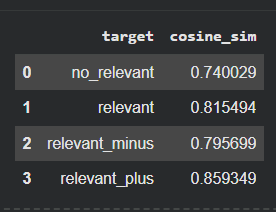

- В ячейке с функцией графовых признаков присутствует ошибочная функция построения графов, обеспечивающая утечку информаци:
- Ошибка заключалась в том что для построения графа брались только релевантные объекты из train. Поэтому на тесте, который является подмножеством train, модель просто знала какие объекты имеют класс relevant, которых 72000 из 211000.
